In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Preparación de datos

In [3]:
data = pd.read_csv('/Users/lizoro/Proyects/CafeLab/Liz/Proyects/Data/reflectancia2025_limpia.csv')


In [4]:
data_acot = data[(data['Wavelength'] >= 220) & (data['Wavelength'] <= 400)]
data_acot = data_acot.reset_index(drop=True)
data_acot


,Wavelength,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde
0,220,26.512730,29.065985,66.308632,37.543079,43.749176,47.601688,47.365265,47.113926
1,221,26.529831,28.958183,65.966629,37.723358,44.215015,47.729950,47.242008,47.235317
2,222,27.183352,29.623117,66.386322,38.470123,44.739548,48.302860,47.998840,47.855606
3,223,27.611547,29.628246,66.363678,38.443802,44.889656,48.636185,48.092403,47.993919
4,224,27.932028,29.891392,66.111221,38.577976,45.066414,48.043468,48.080982,47.968414
...,...,...,...,...,...,...,...,...,...
176,396,19.751076,17.652414,89.534843,28.348627,33.931816,34.321384,37.712200,36.489079
177,397,19.701139,17.618156,89.387993,28.281879,33.870647,34.290634,37.636868,36.469936
178,398,19.723053,17.668360,89.246597,28.307421,33.881271,34.252064,37.633743,36.528751
179,399,19.743473,17.694065,89.051285,28.289989,33.835621,34.282883,37.588600,36.466072


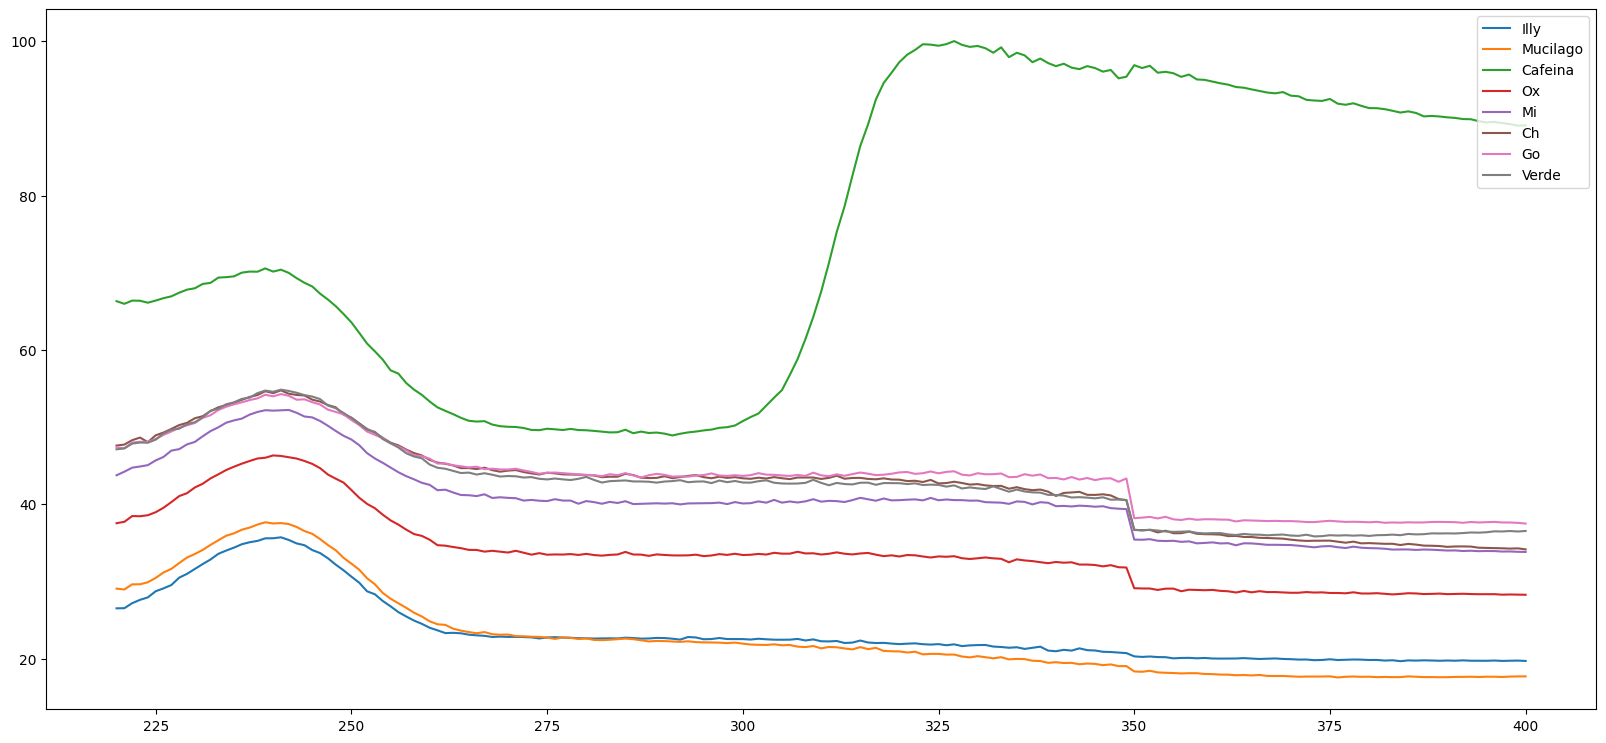

In [5]:
fig = plt.figure(figsize=(20,20))
ax1 = fig.add_subplot(2, 1, 1)

#data_acot_km['Wavelength'] = pd.to_numeric(data_acot_km['Wavelength'],errors = 'coerce')


# Absorbancia
for col in data_acot.columns[1:]:
    df = data_acot
    #print(df)
    #print(col)
    name = col
    ax1.plot(df['Wavelength'], df[name],  label=name)

ax1.set_title("", fontsize=20)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.legend(loc='upper right')

#ax1.set_xlim(220,400)
#ax1.set_xticks([500, 1000, 1500,2000, 2500])

#ax1.set_ylim(0.4,0.8)

#plt.tight_layout()
plt.show()

## Aplicación de la relación KUBELKA-MONK 
### F(R) = (1 − R)^2 / (2*R)

In [6]:
data_acot_fr = (1 - data_acot.iloc[:,:])**2 / (2*data_acot.iloc[:,:])

data_acot_fr.drop(columns=["Wavelength"],inplace=True)

#file_abs.drop(columns=["Wavelength"],inplace=True)
data_acot_fr.head()

,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde
0,12.275224,13.550195,32.161856,17.784858,20.886017,22.811348,22.693189,22.567576
1,12.283762,13.496358,31.990894,17.874933,21.118816,22.875451,22.631588,22.628244
2,12.610069,13.828437,32.200693,18.248059,21.380950,23.161781,23.009837,22.938251
3,12.823882,13.830999,32.189373,18.234907,21.455966,23.328373,23.056598,23.007378
4,12.983915,13.962423,32.063174,18.301949,21.544302,23.032141,23.050890,22.994631


In [7]:
data_acot_fr.dtypes

Illy        float64
Mucilago    float64
Cafeina     float64
Ox          float64
Mi          float64
Ch          float64
Go          float64
Verde       float64
dtype: object

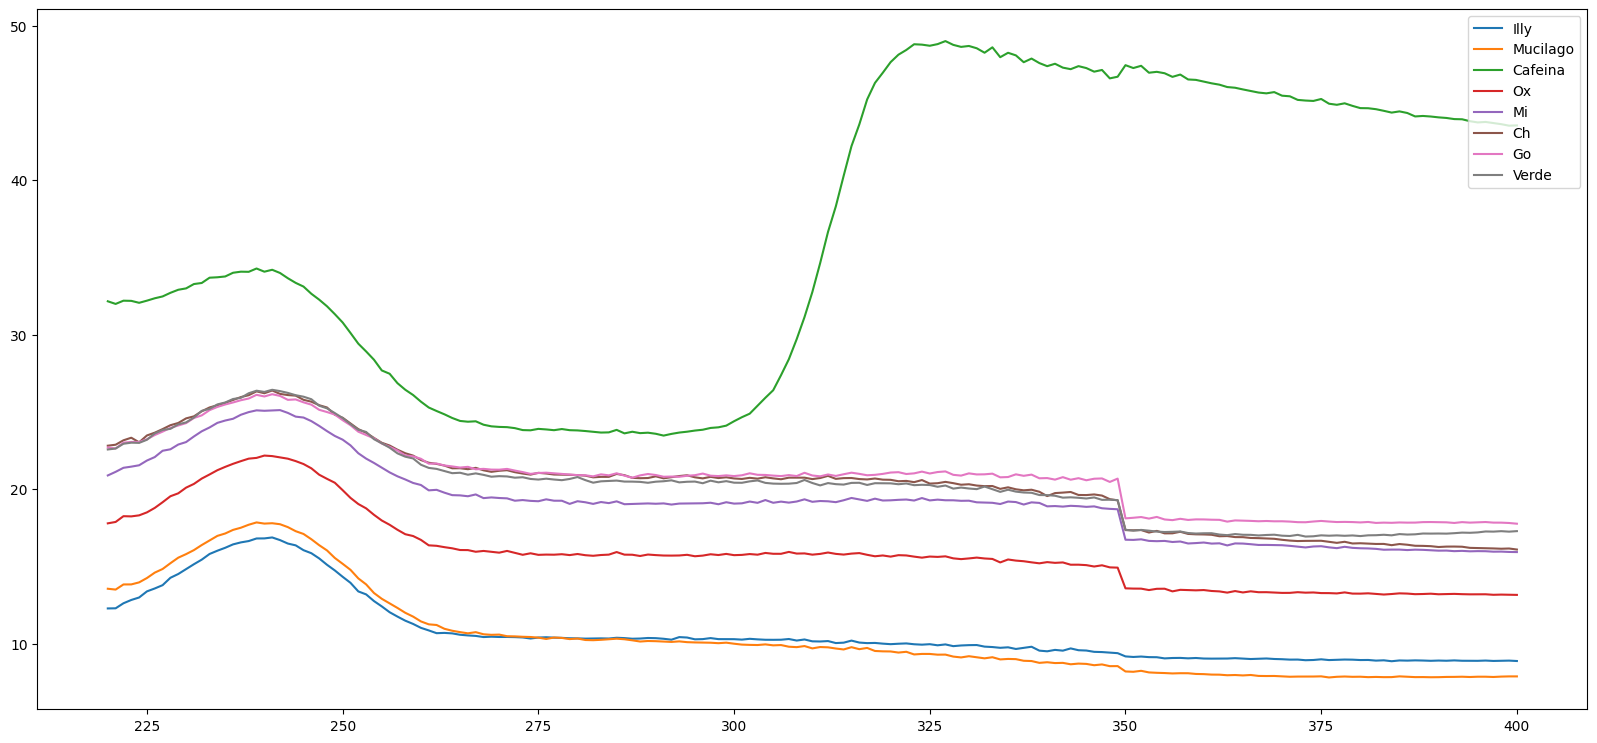

In [8]:
fig = plt.figure(figsize=(20,20))
ax1 = fig.add_subplot(2, 1, 1)

#data_acot_km['Wavelength'] = pd.to_numeric(data_acot_km['Wavelength'],errors = 'coerce')
#data_acot_fr['Wavelength'] = data_acot['Wavelength']
#print(data_acot_fr)
# Absorbancia
for col in data_acot_fr.columns[:]:
    df = data_acot_fr
    df['Wavelength'] = data_acot['Wavelength']

    name = col
    ax1.plot(df['Wavelength'], df[name],  label=name)

ax1.set_title("", fontsize=20)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.legend(loc='upper right')

#ax1.set_xlim(220,400)
#ax1.set_xticks([500, 1000, 1500,2000, 2500])

#ax1.set_ylim(0.4,0.8)

#plt.tight_layout()
plt.show()

In [9]:
data_acot_fr

,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde,Wavelength
0,12.275224,13.550195,32.161856,17.784858,20.886017,22.811348,22.693189,22.567576,220
1,12.283762,13.496358,31.990894,17.874933,21.118816,22.875451,22.631588,22.628244,221
2,12.610069,13.828437,32.200693,18.248059,21.380950,23.161781,23.009837,22.938251,222
3,12.823882,13.830999,32.189373,18.234907,21.455966,23.328373,23.056598,23.007378,223
4,12.983915,13.962423,32.063174,18.301949,21.544302,23.032141,23.050890,22.994631,224
...,...,...,...,...,...,...,...,...,...
176,8.900853,7.854532,43.773006,13.191951,15.980643,16.175260,17.869358,17.258242,396
177,8.875949,7.837458,43.699590,13.158619,15.950086,16.159898,17.831719,17.248678,397
178,8.886878,7.862479,43.628901,13.171374,15.955393,16.140630,17.830158,17.278064,398
179,8.897061,7.875291,43.531257,13.162669,15.932588,16.156026,17.807602,17.246747,399


In [12]:
c = 2.998e8  # velocidad de la luz en m/s
h = 6.626e-34  # constante de Planck en J·s

#v = c/lambda 

v = c / (data_acot_fr['Wavelength'] * 1e-9)  # frecuencia en Hz

#print(v)

data_acot_km = data_acot_fr.copy()
data_acot_km['nu'] = v
data_acot_km.head()


,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde,Wavelength,nu
0,12.275224,13.550195,32.161856,17.784858,20.886017,22.811348,22.693189,22.567576,220,1.362727e+15
1,12.283762,13.496358,31.990894,17.874933,21.118816,22.875451,22.631588,22.628244,221,1.356561e+15
2,12.610069,13.828437,32.200693,18.248059,21.380950,23.161781,23.009837,22.938251,222,1.350450e+15
3,12.823882,13.830999,32.189373,18.234907,21.455966,23.328373,23.056598,23.007378,223,1.344395e+15
4,12.983915,13.962423,32.063174,18.301949,21.544302,23.032141,23.050890,22.994631,224,1.338393e+15


In [13]:
energia_foton = h * v
#print(energia_foton.head())

data_energia = data_acot_km.mul(energia_foton, axis=0) #multiplicamos cada columna por la energia del foton

data_energia = data_energia**2 #elevamos al cuadrado
data_energia.head()

,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde,Wavelength,nu
0,1.228513e-34,1.496966e-34,8.433405e-34,2.578823e-34,3.556575e-34,4.242508e-34,4.198671e-34,4.152318e-34,3.946082e-32,0.000002
1,1.219114e-34,1.471685e-34,8.268645e-34,2.581490e-34,3.603468e-34,4.227863e-34,4.138201e-34,4.136979e-34,3.946082e-32,0.000001
2,1.273196e-34,1.531110e-34,8.302150e-34,2.666205e-34,3.660279e-34,4.295405e-34,4.239233e-34,4.212896e-34,3.946082e-32,0.000001
3,1.304955e-34,1.517971e-34,8.222075e-34,2.638539e-34,3.653024e-34,4.318424e-34,4.218391e-34,4.200400e-34,3.946082e-32,0.000001
4,1.325810e-34,1.533175e-34,8.085057e-34,2.634297e-34,3.650354e-34,4.171946e-34,4.178741e-34,4.158368e-34,3.946082e-32,0.000001


In [14]:
# Limpiamos el dataframe
data_energia["hv"] = energia_foton
data_energia.drop(columns=["Wavelength","nu"],inplace=True)
data_energia.head()

,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde,hv
0,1.228513e-34,1.496966e-34,8.433405e-34,2.578823e-34,3.556575e-34,4.242508e-34,4.198671e-34,4.152318e-34,9.029431e-19
1,1.219114e-34,1.471685e-34,8.268645e-34,2.581490e-34,3.603468e-34,4.227863e-34,4.138201e-34,4.136979e-34,8.988574e-19
2,1.273196e-34,1.531110e-34,8.302150e-34,2.666205e-34,3.660279e-34,4.295405e-34,4.239233e-34,4.212896e-34,8.948085e-19
3,1.304955e-34,1.517971e-34,8.222075e-34,2.638539e-34,3.653024e-34,4.318424e-34,4.218391e-34,4.200400e-34,8.907959e-19
4,1.325810e-34,1.533175e-34,8.085057e-34,2.634297e-34,3.650354e-34,4.171946e-34,4.178741e-34,4.158368e-34,8.868191e-19


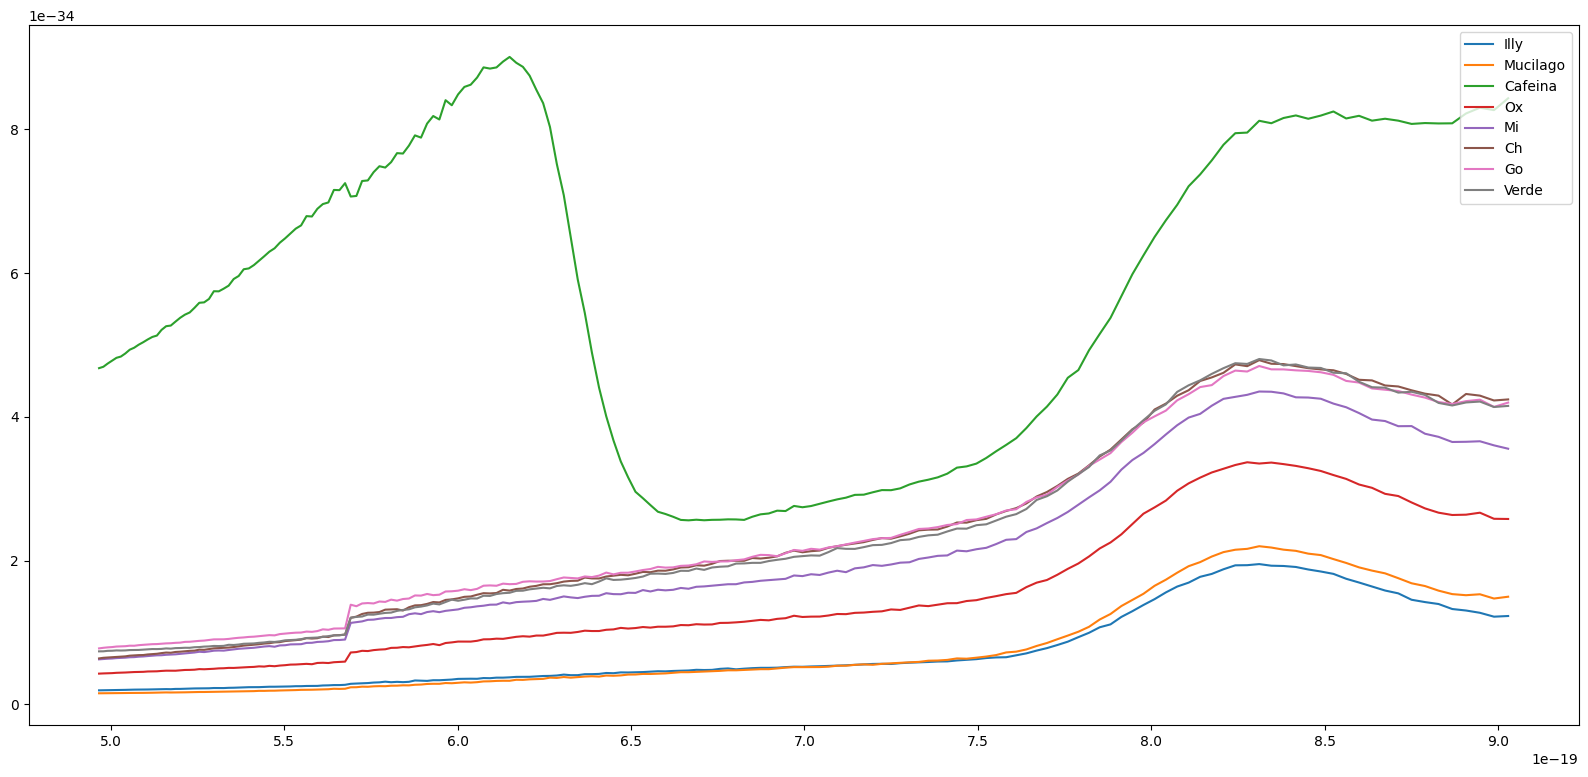

In [15]:
fig = plt.figure(figsize=(20,20))
ax1 = fig.add_subplot(2, 1, 1)


# Absorbancia
for col in data_energia.columns[:-1]:
    df = data_energia

    name = col
    ax1.plot(df['hv'], df[name],  label=name)

ax1.set_title("", fontsize=20)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.legend(loc='upper right')

#ax1.set_xlim(220,400)
#ax1.set_xticks([500, 1000, 1500,2000, 2500])

#ax1.set_ylim(0.4,0.8)

#plt.tight_layout()
plt.show()

In [16]:
# Convirtiendo hv a eV
data_energia['hv'] = data_energia['hv'] / 1.602e-19
data_energia.head()


,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde,hv
0,1.228513e-34,1.496966e-34,8.433405e-34,2.578823e-34,3.556575e-34,4.242508e-34,4.198671e-34,4.152318e-34,5.636349
1,1.219114e-34,1.471685e-34,8.268645e-34,2.581490e-34,3.603468e-34,4.227863e-34,4.138201e-34,4.136979e-34,5.610845
2,1.273196e-34,1.531110e-34,8.302150e-34,2.666205e-34,3.660279e-34,4.295405e-34,4.239233e-34,4.212896e-34,5.585571
3,1.304955e-34,1.517971e-34,8.222075e-34,2.638539e-34,3.653024e-34,4.318424e-34,4.218391e-34,4.200400e-34,5.560524
4,1.325810e-34,1.533175e-34,8.085057e-34,2.634297e-34,3.650354e-34,4.171946e-34,4.178741e-34,4.158368e-34,5.535700


In [ ]:
#data_energia.to_csv('/Users/lizoro/Proyects/CafeLab/Liz/Proyects/Data/data_km.csv', index=False)    

In [27]:
# Normalizando los datos
data_energia_norm = data_energia.copy()
data_energia_norm.iloc[:,:-1] = data_energia_norm.iloc[:,:-1] / (1e-34)
#data_energia_norm.iloc[:, :-1] = data_energia_norm.iloc[:, :-1] / (1e-34)

data_energia_norm.head()

,Illy,Mucilago,Cafeina,Ox,Mi,Ch,Go,Verde,hv
0,1.228513,1.496966,8.433405,2.578823,3.556575,4.242508,4.198671,4.152318,5.636349
1,1.219114,1.471685,8.268645,2.581490,3.603468,4.227863,4.138201,4.136979,5.610845
2,1.273196,1.531110,8.302150,2.666205,3.660279,4.295405,4.239233,4.212896,5.585571
3,1.304955,1.517971,8.222075,2.638539,3.653024,4.318424,4.218391,4.200400,5.560524
4,1.325810,1.533175,8.085057,2.634297,3.650354,4.171946,4.178741,4.158368,5.535700


In [ ]:
#data_energia_norm.to_csv('/Users/lizoro/Proyects/CafeLab/Liz/Proyects/Data/data_km_norm.csv', index=False)